# **Data preprocessing for ML**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv(r'/content/drive/MyDrive/Road_Accident_Risk_Predictor/train.csv')
df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [ ]:
df=df.drop(columns=['id'],axis=1)

###**Data Preprocessing**

In [ ]:
x = df.drop(columns=['accident_risk'],axis=1)
y = df['accident_risk']

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((414203, 12), (103551, 12), (414203,), (103551,))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder, MinMaxScaler

In [ ]:
min_max=MinMaxScaler()
min_max

MinMaxScaler()

In [ ]:
cols_for_scaling=['num_lanes','speed_limit','num_reported_accidents']
cols_for_oe=['road_signs_present','public_road','holiday','school_season']
cols_for_ohe=['road_type','lighting','weather','time_of_day']

In [ ]:
order_oe=['False','True']
oe=OrdinalEncoder(categories=order_oe)
ohe=OneHotEncoder()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

ct1 = ColumnTransformer(transformers=[('binary_oe', OrdinalEncoder(), cols_for_oe),
 ('onehot', OneHotEncoder( drop='first',handle_unknown='ignore', sparse_output=False), cols_for_ohe),
 ('min_max',MinMaxScaler(),cols_for_scaling)  ], verbose_feature_names_out=False).set_output(transform='pandas')


In [ ]:
ct1

ColumnTransformer(transformers=[('binary_oe', OrdinalEncoder(),
                                 ['road_signs_present', 'public_road',
                                  'holiday', 'school_season']),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['road_type', 'lighting', 'weather',
                                  'time_of_day']),
                                ('min_max', MinMaxScaler(),
                                 ['num_lanes', 'speed_limit',
                                  'num_reported_accidents'])],
                  verbose_feature_names_out=False)

In [ ]:
x_train_transformed =ct1.fit_transform(x_train)
x_train_transformed

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents
143159,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714
20172,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857
57926,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857
193319,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857
213938,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.777778,0.142857
365838,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.666667,1.000000,0.142857
131932,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,1.000000,0.285714
146867,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.666667,0.777778,0.571429


In [ ]:
numerical_cols_train=x_train['curvature']
numerical_cols_train

,curvature
143159,0.43
20172,0.18
57926,0.20
193319,0.81
213938,0.43
...,...
259178,0.05
365838,0.47
131932,0.51
146867,0.91


In [ ]:
x_train_transformed_final = pd.concat([x_train_transformed, numerical_cols_train], axis=1)


In [ ]:
x_train_transformed_final

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.777778,0.142857,0.05
365838,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.666667,1.000000,0.142857,0.47
131932,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,1.000000,0.285714,0.51
146867,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.666667,0.777778,0.571429,0.91


In [ ]:
x_train_transformed_final.corr()

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
road_signs_present,1.000000,0.004449,-0.003972,0.002032,0.000655,0.000450,0.000152,-0.006449,-0.004561,0.006122,-0.005125,0.008629,0.000764,-0.004065,0.000228,0.018103
public_road,0.004449,1.000000,-0.008605,0.003589,-0.002103,0.000218,-0.000635,-0.000173,-0.000561,0.010326,-0.000910,0.002555,-0.001927,0.011724,-0.006558,0.048845
holiday,-0.003972,-0.008605,1.000000,-0.001711,-0.001952,-0.001829,-0.006212,0.016515,-0.003275,0.022843,-0.002987,0.004858,0.002720,0.011683,-0.014144,0.063315
school_season,0.002032,0.003589,-0.001711,1.000000,-0.003402,0.002079,0.002927,-0.003228,-0.003917,0.003824,-0.005930,0.012534,0.000252,0.004576,0.003536,-0.005469
road_type_rural,0.000655,-0.002103,-0.001952,-0.003402,1.000000,-0.497451,0.006044,-0.012049,-0.001667,-0.002681,-0.002231,0.000347,0.000228,0.001102,-0.005067,-0.001552
road_type_urban,0.000450,0.000218,-0.001829,0.002079,-0.497451,1.000000,-0.007863,0.012050,0.006112,0.009950,0.004817,-0.003118,0.001368,0.008599,0.004748,0.011079
lighting_dim,0.000152,-0.000635,-0.006212,0.002927,0.006044,-0.007863,1.000000,-0.487078,0.012731,0.028378,-0.003954,-0.000860,0.002919,0.030472,-0.031659,-0.008411
lighting_night,-0.006449,-0.000173,0.016515,-0.003228,-0.012049,0.012050,-0.487078,1.000000,-0.023312,-0.046623,0.003702,0.003693,-0.001216,-0.076129,0.051162,0.000780
weather_foggy,-0.004561,-0.000561,-0.003275,-0.003917,-0.001667,0.006112,0.012731,-0.023312,1.000000,-0.484796,0.020139,-0.017343,0.001211,-0.000553,0.001230,0.045666
weather_rainy,0.006122,0.010326,0.022843,0.003824,-0.002681,0.009950,0.028378,-0.046623,-0.484796,1.000000,-0.011485,0.013854,-0.005689,-0.079675,0.037733,-0.064293


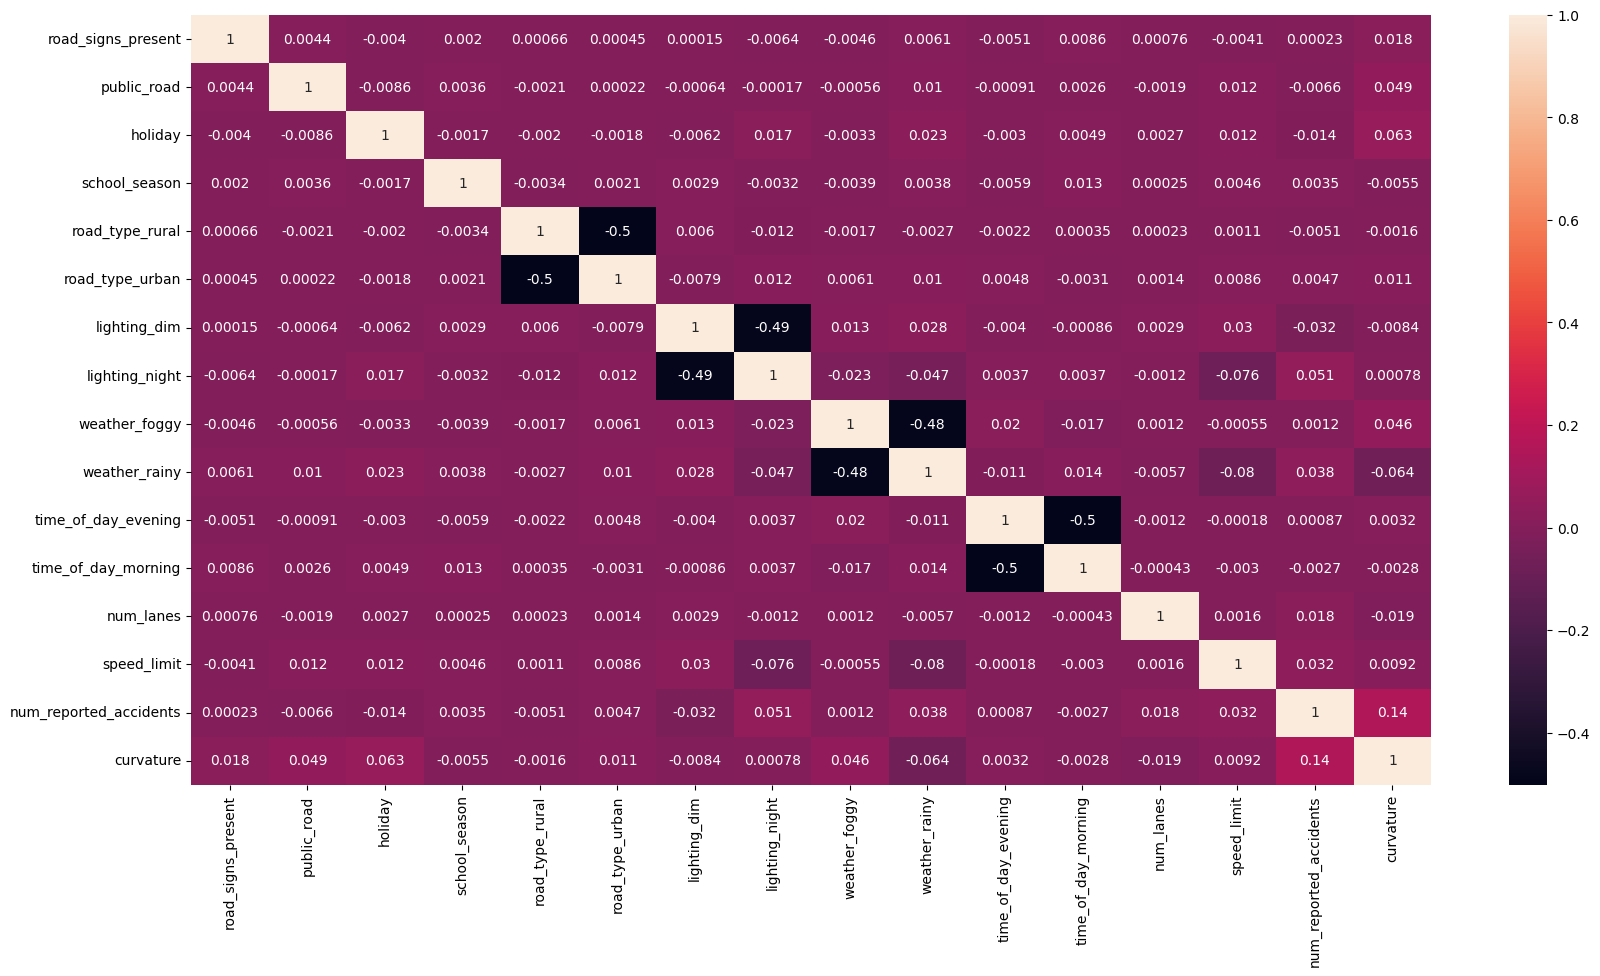

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(x_train_transformed_final.corr(),annot=True);

In [ ]:
x_test_transformed = ct1.transform(x_test)
x_test_transformed

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents
50309,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.444444,0.285714
95219,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.777778,0.000000
197653,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.333333,0.000000,0.000000
111236,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.777778,0.142857
147247,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.777778,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453214,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.333333,0.000000,0.000000
190565,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.666667,0.444444,0.000000
357332,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.333333,0.444444,0.142857
503653,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.285714


In [ ]:
numerical_cols_test=x_test['curvature']
numerical_cols_test

,curvature
50309,0.09
95219,0.14
197653,0.51
111236,0.33
147247,0.12
...,...
453214,0.19
190565,0.63
357332,0.68
503653,0.43


In [ ]:
x_test_transformed_final = pd.concat([x_test_transformed,numerical_cols_test], axis=1)
x_test_transformed_final

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
50309,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.444444,0.285714,0.09
95219,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.777778,0.000000,0.14
197653,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.333333,0.000000,0.000000,0.51
111236,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.777778,0.142857,0.33
147247,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.777778,0.142857,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453214,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.333333,0.000000,0.000000,0.19
190565,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.666667,0.444444,0.000000,0.63
357332,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.333333,0.444444,0.142857,0.68
503653,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.285714,0.43


In [ ]:
import statsmodels.api as sm
# Statsmodels provides a comprehensive statistical report

# **dropping 1**

In [ ]:
x_train_const= sm.add_constant(x_train_transformed_final)
x_train_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
# Instantiate OLS model, Order matters - (y_train, X_train)

ols_obj = sm.OLS(y_train, x_train_const)
ols_obj

In [ ]:
ols = ols_obj.fit()
ols

In [ ]:
# Parameters of model

ols.params

,0
const,-0.048950
road_signs_present,-0.001330
public_road,-0.000697
holiday,-0.000399
school_season,0.000341
road_type_rural,-0.000708
road_type_urban,0.000001
lighting_dim,-0.000171
lighting_night,0.187101
weather_foggy,0.091868


In [ ]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.070e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:18:39   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414186   BIC:                        -9.870e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['features'] = x_train_transformed_final.columns
vif['vif'] = [variance_inflation_factor(x_train_transformed_final.values, var) for var in range(x_train_transformed_final.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif


,features,vif
15,curvature,3.851237
14,num_reported_accidents,2.719369
13,speed_limit,2.551757
12,num_lanes,2.532929
2,holiday,1.953745
1,public_road,1.933746
0,road_signs_present,1.904646
3,school_season,1.896729
6,lighting_dim,1.880277
8,weather_foggy,1.876894


In [ ]:
x_train_1 = x_train_transformed_final.drop(['road_type_urban'], axis = 1)

In [ ]:
x_train_1_const = sm.add_constant(x_train_1)
x_train_1_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols1_obj = sm.OLS(y_train,x_train_1_const)
ols1 = ols1_obj.fit()
ols1

In [ ]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.141e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:19:03   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414187   BIC:                        -9.870e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_1.columns
vif['vif'] = [variance_inflation_factor(x_train_1.values, var) for var in range(x_train_1.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
14,curvature,3.804427
13,num_reported_accidents,2.711315
12,speed_limit,2.525321
11,num_lanes,2.515090
2,holiday,1.949579
1,public_road,1.928659
0,road_signs_present,1.898160
3,school_season,1.890159
5,lighting_dim,1.870555
7,weather_foggy,1.862240


# **dropping 2**

In [ ]:
x_train_2 = x_train_1.drop(['lighting_dim'], axis = 1)

In [ ]:
x_train_2_const = sm.add_constant(x_train_2)
x_train_2_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols2_obj = sm.OLS(y_train,x_train_2_const)
ols2 = ols2_obj.fit()
ols2

In [ ]:
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.223e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:19:19   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414188   BIC:                        -9.870e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_2.columns
vif['vif'] = [variance_inflation_factor(x_train_2.values, var) for var in range(x_train_2.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
13,curvature,3.763055
12,num_reported_accidents,2.702474
11,speed_limit,2.502106
10,num_lanes,2.491057
2,holiday,1.942253
1,public_road,1.921465
0,road_signs_present,1.890600
3,school_season,1.881119
6,weather_foggy,1.846194
9,time_of_day_morning,1.841622


# **dropping 3**

In [ ]:
x_train_3 = x_train_2.drop(['school_season'], axis = 1)

In [ ]:
x_train_3_const = sm.add_constant(x_train_3)
x_train_3_const.head()

,const,road_signs_present,public_road,holiday,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols3_obj = sm.OLS(y_train,x_train_3_const)
ols3 = ols3_obj.fit()
ols3

In [ ]:
print(ols3.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.317e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:19:34   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414189   BIC:                        -9.871e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_3.columns
vif['vif'] = [variance_inflation_factor(x_train_3.values, var) for var in range(x_train_3.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
12,curvature,3.732592
11,num_reported_accidents,2.693059
10,speed_limit,2.480516
9,num_lanes,2.474409
2,holiday,1.937567
1,public_road,1.915294
0,road_signs_present,1.884025
5,weather_foggy,1.836433
7,time_of_day_evening,1.829126
8,time_of_day_morning,1.828576


# **dropping 4**

In [ ]:
x_train_4=x_train_3.drop(['holiday'],axis=1)

In [ ]:
x_train_4_const = sm.add_constant(x_train_4)
x_train_4_const.head()

,const,road_signs_present,public_road,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols4_obj = sm.OLS(y_train,x_train_4_const)
ols4 = ols4_obj.fit()
ols4

In [ ]:
print(ols4.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.426e+05
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:19:47   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414190   BIC:                        -9.871e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_4.columns
vif['vif'] = [variance_inflation_factor(x_train_4.values, var) for var in range(x_train_4.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
11,curvature,3.630846
10,num_reported_accidents,2.691741
8,num_lanes,2.458301
9,speed_limit,2.455779
1,public_road,1.912880
0,road_signs_present,1.879833
4,weather_foggy,1.824562
6,time_of_day_evening,1.821061
7,time_of_day_morning,1.819240
5,weather_rainy,1.690757


In [ ]:
x_train_4

,road_signs_present,public_road,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43
...,...,...,...,...,...,...,...,...,...,...,...,...
259178,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.777778,0.142857,0.05
365838,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.666667,1.000000,0.142857,0.47
131932,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,1.000000,0.285714,0.51
146867,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.666667,0.777778,0.571429,0.91


In [ ]:
x_train_4.columns

Index(['road_signs_present', 'public_road', 'road_type_rural',
       'lighting_night', 'weather_foggy', 'weather_rainy',
       'time_of_day_evening', 'time_of_day_morning', 'num_lanes',
       'speed_limit', 'num_reported_accidents', 'curvature'],
      dtype='object')

In [ ]:
x_test_new = x_test_transformed_final[x_train_4.columns]
x_test_new

,road_signs_present,public_road,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
50309,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.444444,0.285714,0.09
95219,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.777778,0.000000,0.14
197653,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.333333,0.000000,0.000000,0.51
111236,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.777778,0.142857,0.33
147247,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.777778,0.142857,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...
453214,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.333333,0.000000,0.000000,0.19
190565,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.666667,0.444444,0.000000,0.63
357332,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.333333,0.444444,0.142857,0.68
503653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.285714,0.43


# **Model Building**

##**DecisionTreeRegressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
dt=DecisionTreeRegressor()
dt

DecisionTreeRegressor()

In [ ]:
dt.fit(x_train_4,y_train)

DecisionTreeRegressor()

In [ ]:
dt.score(x_train_4,y_train)

0.972414346549076

In [ ]:
y_pred=dt.predict(x_test_new)
y_pred.shape

(103551,)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.7747840195454759

0.0062187074037873425

0.06065478746535907

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = DecisionTreeRegressor(random_state=42)

param_dist = {
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 30),
    "criterion": ["squared_error"],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,                       # number of random trials
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_4, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7942406b1190>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7942403b9010>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x794244dcbe60>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
search.best_params_

{'criterion': 'squared_error',
 'max_depth': 9,
 'min_samples_leaf': 20,
 'min_samples_split': 30}

In [ ]:
search.best_score_


np.float64(-0.003201833805001931)

In [ ]:
search.best_estimator_


DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30,
                      random_state=42)

In [ ]:
dt=DecisionTreeRegressor(**search.best_params_)
dt

DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30)

In [ ]:
dt.fit(x_train_4,y_train)

DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30)

In [ ]:
dt.score(x_train_4,y_train)

0.885732638429113

In [ ]:
y_pred=dt.predict(x_test_new)
y_pred

array([0.13205272, 0.33145038, 0.25069249, ..., 0.40795794, 0.14019116,
       0.15706609])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8835703822290052

0.0032148772240379064

0.04396034724693274

## **RandomForestRegressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=30)
rf

RandomForestRegressor(n_estimators=30)

In [ ]:
rf.fit(x_train_4,y_train)

RandomForestRegressor(n_estimators=30)

In [ ]:
rf.score(x_train_4,y_train)

0.9600810372686093

In [ ]:
y_pred=rf.predict(x_test_new)
y_pred

array([0.15702778, 0.36188889, 0.28223333, ..., 0.40484444, 0.17883333,
       0.15414603])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8530383324610955

0.004057934113523788

0.04933711244353657

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = RandomForestRegressor(random_state=42)

param_forest = {
    "n_estimators": randint(2,20),
    'criterion':['squared_error'],
    'max_depth': randint(2,30),
    'min_samples_split' : randint(2,30),
    'min_samples_leaf': randint(2,30),
    }
search=RandomizedSearchCV(estimator=model,
                          param_distributions=param_forest,
                          n_iter=10,
                          scoring="neg_mean_squared_error",
                          cv=cv,
                          n_jobs=-1,
                          random_state=42,
                          verbose=1)
search.fit(x_train_4,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79424071b260>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79423f109760>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79423f109640>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7942403b92e0>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
search.best_params_

{'criterion': 'squared_error',
 'max_depth': 9,
 'min_samples_leaf': 22,
 'min_samples_split': 8,
 'n_estimators': 12}

In [ ]:
search.best_estimator_

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12, random_state=42)

In [ ]:
search.best_score_

np.float64(-0.003192775562425076)

In [ ]:
rf=RandomForestRegressor(**search.best_params_)
rf

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12)

In [ ]:
rf.fit(x_train_4,y_train)

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12)

In [ ]:
rf.score(x_train_4,y_train)

0.8860321480691085

In [ ]:
y_pred=rf.predict(x_test_new)
y_pred

array([0.12884402, 0.33202734, 0.25142982, ..., 0.41189957, 0.14002727,
       0.15750041])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8839203265812595

0.003205214492601685

0.04388653426512181

##**LinearRegressor**

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import loguniform

cv = KFold(n_splits=3, shuffle=True, random_state=42)

model_type = "ElasticNet"  # "Ridge", "Lasso", or "ElasticNet"

if model_type == "Ridge":
    model = Ridge(random_state = 42)
    param_dist = {
        "alpha": loguniform(1e-4, 1e2)
    }

elif model_type == "Lasso":
    model = Lasso(max_iter=10000,random_state = 42)
    param_dist = {
        "alpha": loguniform(1e-4, 1e2)
    }

elif model_type == "ElasticNet":
    model = ElasticNet(max_iter=10000,random_state = 42)
    param_dist = {
        "alpha": loguniform(1e-4, 1e2),
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="neg_mean_squared_error",
    random_state=42
)

search.fit(x_train_4, y_train)

RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=ElasticNet(max_iter=10000, random_state=42),
                   n_iter=20,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x794244db4c20>,
                                        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
search.best_params_

{'alpha': np.float64(0.00013289448722869195), 'l1_ratio': 0.3}

In [ ]:
search.best_estimator_


ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3,
           max_iter=10000, random_state=42)

In [ ]:
en=ElasticNet(**search.best_params_)
en

ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3)

In [ ]:
en.fit(x_train_4,y_train)

ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3)

In [ ]:
en.score(x_train_4,y_train)

0.8051436563728287

In [ ]:
y_pred=en.predict(x_test_new)
y_pred

array([0.20641034, 0.26835894, 0.20965018, ..., 0.4757864 , 0.12355873,
       0.22769922])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8041856608970817

0.00540686357109071

0.058306879420443394

##**Saving the Best Model for Deployment**

#### **I want to use RandomForest Model for Deployment because it's Training and Testing Scores are comparatively high as compared to other models**

In [ ]:
import pickle

# 1. Create model
rf = rf.fit(x_train_4,y_train)


# 2. Save the FITTED model
with open("rf.pkl", "wb") as file:
  pickle.dump(rf, file)


from google.colab import files
files.download("rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>